# Homework 1.1

In [24]:
# using deepseek API

# Create the API key here:
# https://platform.deepseek.com/api_keys

# Install the required library
!pip install -q -U openai

# install dotenv
!pip install -q python-dotenv

In [25]:
from dotenv import load_dotenv
import os
from openai import OpenAI

load_dotenv()
api_key = os.getenv("DEEPSEEK_API_KEY")
client = OpenAI(
    api_key=api_key,
    base_url="https://api.deepseek.com"
)

print("Deepseek API initialized successfully")

Deepseek API initialized successfully


In [26]:
# read all files in the articles directory
articles = {}
for filename in os.listdir("articles"):
    with open(os.path.join("articles", filename), "r") as f:
        articles[filename] = f.read()
        
print(f"Read {len(articles)} articles.")

Read 10 articles.


In [27]:
import time

# Tell the model to be a helpful assistant that summarizes articles. 
# Provide how you want the summary to be formatted.
instructions = """
You are a helpful assistant that summarizes articles.
Summarize the articles to a person who has not read them nor knows anything about them or the topic.
Output constraints:
- Output 5 bullet points.
- Each bullet point should be no more than 1-2 sentences long.
- Keep the sentences simple and easy to understand, avoiding technical jargon.
- One sentence should be no more than 20 words.
- Neutral tone, no opinions or assumptions.
- Output just the bullet points, no other text.
"""

def ask(text):
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": instructions},
            {"role": "user", "content": text}
        ],
        temperature=0.2,
    )
    return response.choices[0].message.content

summaries = {}
for filename, content in articles.items():
    print(f"Summarizing {filename}...")
    retries = 3
    timeout = 10
    while retries > 0:
        try:
            summaries[filename] = ask(content)
            print(f"Summarized {filename}.\n")
            break 
        except Exception as e:
            retries -= 1
            if retries > 0:
                print(f"Error, retrying in {timeout} seconds... ({retries} attempts left)")
                time.sleep(timeout)
            else:
                print(f"Failed after retries: {filename}")
    
    

Summarizing wordpress.txt...
Summarized wordpress.txt.

Summarizing OSM.txt...
Summarized OSM.txt.

Summarizing wayback_machine.txt...
Summarized wayback_machine.txt.

Summarizing wikipedia.txt...
Summarized wikipedia.txt.

Summarizing chatoyancy.txt...
Summarized chatoyancy.txt.

Summarizing youtube.txt...
Summarized youtube.txt.

Summarizing 8086.txt...
Summarized 8086.txt.

Summarizing c_lang.txt...
Summarized c_lang.txt.

Summarizing annas_arch.txt...
Summarized annas_arch.txt.

Summarizing chatgpt.txt...
Summarized chatgpt.txt.



In [28]:
# print all summaries
for filename, summary in summaries.items():
    print(f"Summary of {filename}:\n{summary}\n")
    
# save summaries as json file
import json
with open("summaries.json", "w") as f:
    json.dump(summaries, f, indent=4)

Summary of wordpress.txt:
- WordPress is a free system for building websites and blogs.
- It started as a blog tool but now makes many types of websites.
- Users can change a site's design using themes and add features with plugins.
- It was created in 2003 and is very popular for building websites.
- To use it, you need to install it on a web server or hosting service.

Summary of OSM.txt:
- OpenStreetMap is a free map database created by volunteers.
- It started in 2004 because UK map data was not freely available.
- The project is supported by a non-profit foundation funded by donations.
- Many companies now use its data, especially after Google Maps introduced fees.
- The map stores locations using points, lines, and grouped relationships.

Summary of wayback_machine.txt:
- It is a free online archive of old websites.
- It was launched to the public in 2001.
- It saves copies of web pages as they change over time.
- Users can view how a website looked on a past date.
- It has archi

# Homework 1.2.2

In [65]:
# In this one we will generate 1000 random numbers uniformly distributed between 0 and 1

import uuid


needed = 1000
batch_limit = 100
timeout = 10

def generate(count, random_seed):
    prompt = f"""
        Generate {count} random numbers uniformly distributed between 0 and 1.
        Output the numbers as a JSON array, with no other text.
        The numbers should have 3 decimal places of precision.
        Example output:
        {{
            "numbers": [0.123, 0.456, 0.789, ...]
        }}
        Do not output anything other than the JSON array.
        Do not include markdown formatting or code blocks, just the raw JSON.
        {random_seed}
        """
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": "You are a helpful assistant that generates random numbers."},
            {"role": "user", "content": prompt}
        ],
        temperature=2,
    )
    return response.choices[0].message.content

all_numbers = {}
num_count = 0
iteration = 0
while num_count < needed:
    print(f"Generating numbers... ({num_count}/{needed})")
    try:
        count = min(batch_limit, needed - num_count)
        # random_seed = f"Random noise seed: {uuid.uuid4()}"
        random_seed = ""
        print(f"-   Requesting {count} numbers")
        print(f"-   Using random seed: {random_seed}")
        
        output = generate(count, random_seed)
        print(f"Output received: \n{output}")
        
        data = json.loads(output)
        numbers = data.get("numbers", [])
        all_numbers[iteration] = numbers
        num_count += len(numbers)
        print(f"Generated {len(numbers)} numbers.")
        
        iteration += 1
    except Exception as e:
        print(f"Error generating numbers: {e}")
        print(f"Retrying in {timeout} seconds...")
        time.sleep(timeout)
    finally:
        print("-" * 40)

Generating numbers... (0/1000)
-   Requesting 100 numbers
-   Using random seed: 
Output received: 
{"numbers": [0.123, 0.456, 0.789, 0.234, 0.567, 0.890, 0.345, 0.678, 0.901, 0.112, 0.113, 0.114, 0.115, 0.116, 0.117, 0.118, 0.119, 0.120, 0.121, 0.122, 0.124, 0.125, 0.126, 0.127, 0.128, 0.129, 0.130, 0.131, 0.132, 0.133, 0.134, 0.135, 0.136, 0.137, 0.138, 0.139, 0.140, 0.141, 0.142, 0.143, 0.144, 0.145, 0.146, 0.147, 0.148, 0.149, 0.150, 0.151, 0.152, 0.153, 0.154, 0.155, 0.156, 0.157, 0.158, 0.159, 0.160, 0.161, 0.162, 0.163, 0.164, 0.165, 0.166, 0.167, 0.168, 0.169, 0.170, 0.171, 0.172, 0.173, 0.174, 0.175, 0.176, 0.177, 0.178, 0.179, 0.180, 0.181, 0.182, 0.183, 0.184, 0.185, 0.186, 0.187, 0.188, 0.189, 0.190, 0.191, 0.192, 0.193, 0.194, 0.195, 0.196, 0.197, 0.198, 0.199, 0.200, 0.201, 0.202]}
Generated 99 numbers.
----------------------------------------
Generating numbers... (99/1000)
-   Requesting 100 numbers
-   Using random seed: 
Output received: 
{
    "numbers": [0.092, 0.47

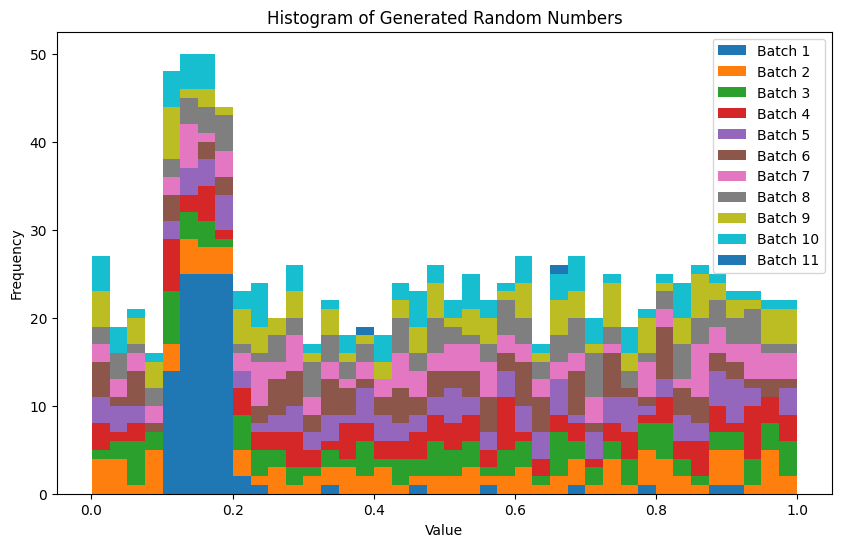

In [66]:
# Now plot them using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
data_to_plot = [all_numbers[batch] for batch in sorted(all_numbers.keys())]
plt.hist(data_to_plot, bins=40, stacked=True, label=[f'Batch {i+1}' for i in range(len(data_to_plot))])
plt.title('Histogram of Generated Random Numbers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()